In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
arxiv_api_wrapper = ArxivAPIWrapper(
    top_k_results = 3, doc_content_chars_max = 500
)
arxiv = ArxivQueryRun(
    api_wrapper = arxiv_api_wrapper, description = "Query arxiv research papers"
)

In [3]:
import arxiv
from langchain_core.tools import tool

@tool("arxiv-paper-search")
def arxiv_search(query: str) -> str:
    """This tool helps to get any types of research papers.

    Args:
        query (str): paper name or paper related query

    Returns:
        list[str]: a list of retrieved papers
    """
    
    client = arxiv.Client()
    search = arxiv.Search(query = query , max_results = 3)
    results = client.results(search)
    papers = []
    
    for r in results:
        paper_details = (
            f"Title: {r.title}\n"
            f"Published: {r.published.strftime('%Y-%m-%d')}\n"
            f"Link: {r.entry_id}\n"
            f"Abstract: {r.summary}\n"
            f"---"
        )
        papers.append(paper_details)
    
    return "\n".join(papers) if papers else "No papers found for this query."

In [4]:
wiki_api_wrapper = WikipediaAPIWrapper(
    top_k_results = 3
)
wikipedia = WikipediaQueryRun(
    api_wrapper = wiki_api_wrapper, description = "Search for latest/unknown information"
)

In [5]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API")

In [6]:
# tavily search tool
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

C:\Users\tipto\AppData\Local\Temp\ipykernel_5136\3616397834.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [7]:
# combine all the tools
tools = [arxiv_search , wikipedia , tavily]

In [8]:
from langchain_groq import ChatGroq
# I dont know why groq's other models are not working.
# TODO: Check for other models
llm = ChatGroq(
    model = "llama-3.1-8b-instant",
    temperature = 0.0
)

In [9]:
llm_with_tools = llm.bind_tools(tools)

In [10]:
response = llm_with_tools.invoke("Todays news on meta's layoff")
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'bsy9yegtv', 'function': {'arguments': '{"query":"Meta layoff news today"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 471, 'total_tokens': 493, 'completion_time': 0.045105089, 'completion_tokens_details': None, 'prompt_time': 0.036945213, 'prompt_tokens_details': None, 'queue_time': 0.170530927, 'total_time': 0.082050302}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4a90-2f6d-7a51-b713-9c05e9e52105-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Meta layoff news today'}, 'id': 'bsy9yegtv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 471, 'output_tokens': 22, 'total_tokens': 493})

### Workflow

In [11]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END

In [12]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage] , add_messages]

In [13]:
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode, tools_condition

In [14]:
# node definition
def tool_calling_llm(state: State):
    message = state['messages']
    response = llm_with_tools.invoke(message)
    return {
        "messages": [response]
    }

In [15]:
graph = StateGraph(State)
graph.add_node("tool_calling_llm" , tool_calling_llm)
graph.add_node("tools" , ToolNode(tools = tools))

graph.add_edge(START , "tool_calling_llm")
graph.add_conditional_edges("tool_calling_llm" , tools_condition)
graph.add_edge("tools" , "tool_calling_llm")
graph.add_edge("tool_calling_llm" , END)

workflow = graph.compile()

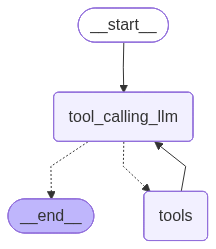

In [16]:
workflow

In [17]:
from langchain_core.messages import HumanMessage

In [18]:
messages = workflow.invoke({
    "messages": [
        HumanMessage(content="Hi, I am tipto. Tell me the most recent research paper's abstract on AI.")
    ]
})

In [19]:
for m  in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi, I am tipto. Tell me the most recent research paper's abstract on AI.
================================== Ai Message ==================================
Tool Calls:
  arxiv-paper-search (h8rbn0s6h)
 Call ID: h8rbn0s6h
  Args:
    query: AI recent research paper
================================= Tool Message =================================
Name: arxiv-paper-search

Title: This paper has been withdrawn
Published: 2003-09-17
Link: http://arxiv.org/abs/cond-mat/0309395v2
Abstract:   This paper has been withdrawn
---
Title: AI prediction leads people to forgo guaranteed rewards
Published: 2026-03-30
Link: http://arxiv.org/abs/2603.28944v1
Abstract: Artificial intelligence (AI) is understood to affect the content of people's decisions. Here, using a behavioral implementation of the classic Newcomb's paradox in 1,305 participants, we show that AI can also change how people decide. In this paradigm, belief in 

In [20]:
len(messages['messages'])

4

In [21]:
messages['messages'][0]

HumanMessage(content="Hi, I am tipto. Tell me the most recent research paper's abstract on AI.", additional_kwargs={}, response_metadata={}, id='bb66eef8-27ba-4f78-8a2f-4f818240dc13')

In [22]:
messages['messages'][1]

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'h8rbn0s6h', 'function': {'arguments': '{"query":"AI recent research paper"}', 'name': 'arxiv-paper-search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 481, 'total_tokens': 501, 'completion_time': 0.029283083, 'completion_tokens_details': None, 'prompt_time': 0.076775775, 'prompt_tokens_details': None, 'queue_time': 0.052817323, 'total_time': 0.106058858}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4a90-31b3-7a20-a291-fe8a5e456810-0', tool_calls=[{'name': 'arxiv-paper-search', 'args': {'query': 'AI recent research paper'}, 'id': 'h8rbn0s6h', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 481, 'output_tokens': 20, 'total_tokens': 501})

In [23]:
len(messages['messages'][2].content)

2592

In [24]:
print(messages['messages'][3].content)

It seems like the first paper has been withdrawn. The most recent research paper's abstract on AI is from "AI prediction leads people to forgo guaranteed rewards" and "Foundations of GenIR".


In [25]:
print(messages['messages'][-1].content)

It seems like the first paper has been withdrawn. The most recent research paper's abstract on AI is from "AI prediction leads people to forgo guaranteed rewards" and "Foundations of GenIR".
